In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    roc_curve
)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [15]:
# Load the dataset
df = pd.read_csv('/content/Data_for_UCI_named.csv')

In [16]:
df.shape

(10000, 14)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [18]:
# Data Cleaning
print("Checking for null values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Checking for null values:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Data Types:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object


In [19]:
# Fill missing values in numerical columns with the mean
for column in df.select_dtypes(include=np.number).columns:
    df[column] = df[column].fillna(df[column].mean())

In [20]:
# Fill missing values in 'stabf' (if any) with mode (do NOT convert to numeric)
if df['stabf'].isnull().any():
    df['stabf'] = df['stabf'].fillna(df['stabf'].mode()[0])

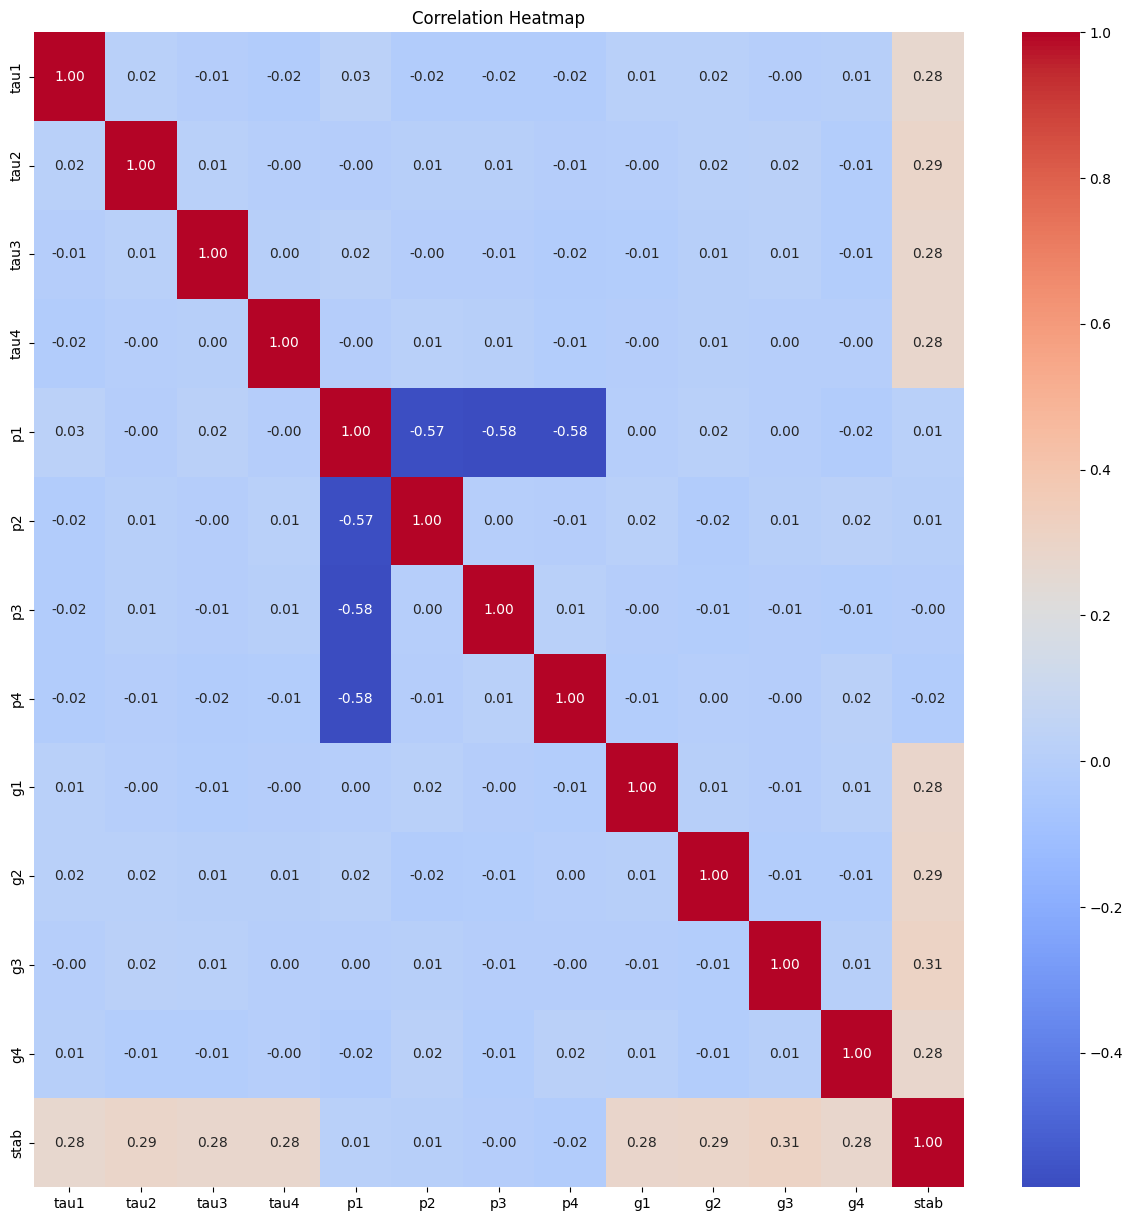

In [22]:
# Correlation heatmap
numerical_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(15, 15))
sns.heatmap(numerical_df.corr(), fmt=".2f", cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [23]:
# Prepare features and target
target_col = 'stabf'
X = df.drop(columns=[target_col])
y = df[target_col]

In [24]:
# Encode target if it's categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    print("\nEncoded target classes:", le.classes_)
    print("Value counts after encoding:\n", pd.Series(y_encoded).value_counts())
else:
    y_encoded = y


Encoded target classes: ['stable' 'unstable']
Value counts after encoding:
 1    6380
0    3620
Name: count, dtype: int64


In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [26]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Classification Models
classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest Classifier': RandomForestClassifier(),
    'Gradient Boosting Classifier': GradientBoostingClassifier(),
    'Support Vector Classifier': SVC(probability=True),
    'K-Nearest Neighbors Classifier': KNeighborsClassifier()
}

# Metrics and ROC Curve Data
print("\n--- Model Performance Metrics ---")
best_model = None
best_acc = 0
roc_data = {}

for name, model in classification_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Get probabilities or decision function for ROC AUC and curve
    try:
        if hasattr(model, "predict_proba"):
            probas = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            probas = model.decision_function(X_test)
        else:
            probas = None
    except:
        probas = None

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probas) if probas is not None else "N/A"

    print(f"\n{name}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"ROC-AUC   : {roc_auc if isinstance(roc_auc, str) else round(roc_auc, 4)}")

    if acc > best_acc:
        best_acc = acc
        best_model = model

    # Store ROC data if available
    if probas is not None:
        fpr, tpr, _ = roc_curve(y_test, probas)
        roc_data[name] = (fpr, tpr, roc_auc)


--- Model Performance Metrics ---

Logistic Regression
Accuracy  : 0.9960
F1 Score  : 0.9969
Precision : 0.9969
Recall    : 0.9969
ROC-AUC   : 1.0

Random Forest Classifier
Accuracy  : 1.0000
F1 Score  : 1.0000
Precision : 1.0000
Recall    : 1.0000
ROC-AUC   : 1.0

Gradient Boosting Classifier
Accuracy  : 1.0000
F1 Score  : 1.0000
Precision : 1.0000
Recall    : 1.0000
ROC-AUC   : 1.0

Support Vector Classifier
Accuracy  : 0.9900
F1 Score  : 0.9922
Precision : 0.9899
Recall    : 0.9945
ROC-AUC   : 0.9996

K-Nearest Neighbors Classifier
Accuracy  : 0.9380
F1 Score  : 0.9524
Precision : 0.9337
Recall    : 0.9718
ROC-AUC   : 0.9799


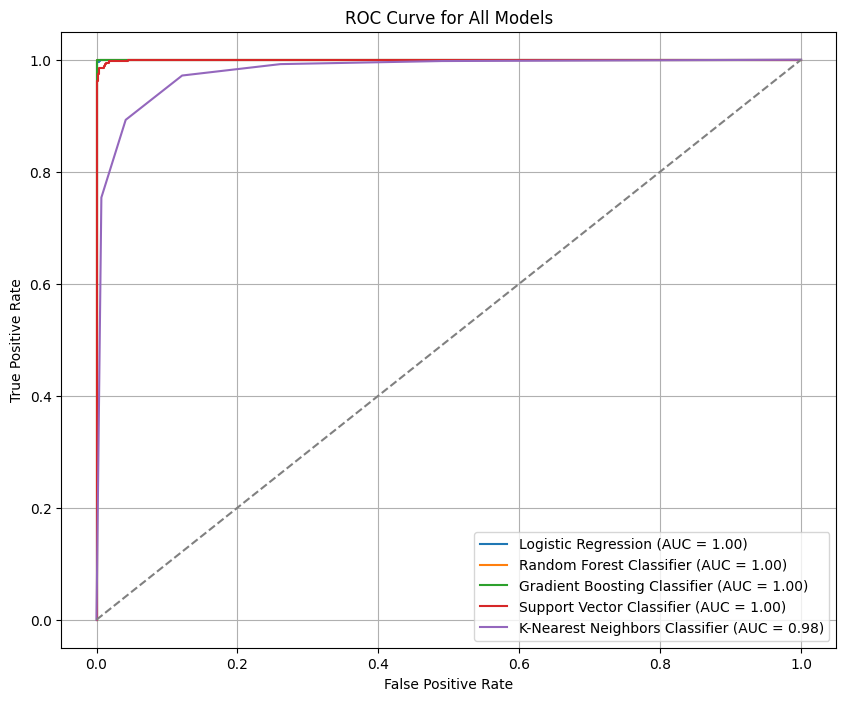

In [28]:
# Plot ROC Curves
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# ====== User Input for Prediction ======
print("\nEnter values for the following parameters to check system stability:")
user_input = []

for col in X.columns:
    val = float(input(f"Enter value for {col}: "))
    user_input.append(val)

# Scale and predict
user_input_scaled = scaler.transform([user_input])
prediction = best_model.predict(user_input_scaled)

# Decode prediction if label encoder was used
if 'le' in locals() and isinstance(prediction[0], (int, np.integer)):
    prediction_label = le.inverse_transform([prediction[0]])[0]
else:
    prediction_label = prediction[0]

print(f"\nPredicted System Stability Status: {prediction_label}")
0


Enter values for the following parameters to check system stability:
Enter value for tau1: 9.307
Enter value for tau2: 4.902
Enter value for tau3: 3.047
Enter value for tau4: 1.36
Enter value for p1: 5.0678
Enter value for p2: -1.9400
Enter value for p3: -1.8727
Enter value for p4: -1.2550
Enter value for g1: 0.413
Enter value for g2: .862
Enter value for g3: 0.562
Enter value for g4: 0.781
Enter value for stab: -0.0053

Predicted System Stability Status: stable


In [32]:
import pickle

# Save the trained model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the label encoder (only if used)
if 'le' in locals():
    with open('Label_encoder.pkl', 'wb') as f:
        pickle.dump(le, f)


In [33]:
from google.colab import files

files.download('best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from google.colab import files

files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
from google.colab import files

files.download('Label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>